<div style="margin-bottom: 32px;">
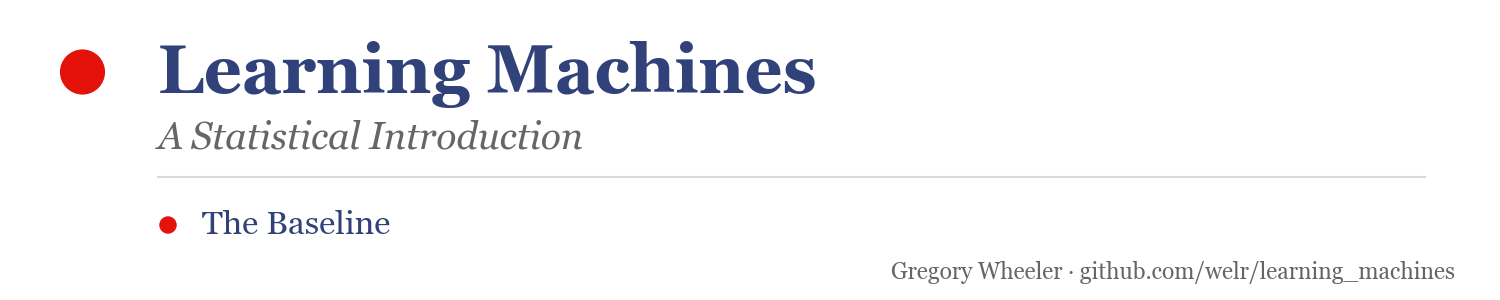
</div>


# The Baseline: What Any Model Must Beat

Before fitting anything, fix a **baseline**: the simplest model that ignores the inputs entirely and predicts the same value every time. Every later chapter is an attempt to beat it.

**What computation adds**: The text argues that prediction is judged against a standard. Here we compute that standard on the Frankfurt housing data, show that the mean is not an arbitrary choice but the minimizer of squared error, and measure exactly what one feature buys.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd()))

# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt
plt.style.use('mlone_style.mplstyle')
mt.set_notebook_mode()  # Green-primary palette for notebooks

## 1. The Data

Twenty Frankfurt sales: living area in square meters, price in thousands of euros. These are the points plotted on the companion site's landing page, and the first three are the first three rows of the Chapter 2 table (52 m2 / 164, 82 / 384, 120 / 465), rounded.

In [2]:
area = np.array([ 52,  82, 120,  95, 140, 160, 180, 200, 210, 225,
                 150, 110, 130, 170, 190, 205, 240,  60,  75, 100.])
price = np.array([164, 384, 465, 420, 520, 610, 700, 760, 820, 900,
                  560, 430, 500, 650, 720, 790, 980, 260, 330, 410.])

m = len(price)
print(f"{m} sales, {area.min():.0f}-{area.max():.0f} m2, "
      f"{price.min():.0f}-{price.max():.0f} thousand euros")

20 sales, 52-240 m2, 164-980 thousand euros


## 2. The Baseline

The baseline ignores `area` and predicts one number for every house. Take that number to be the mean, and measure what it leaves behind with mean squared error.

In [3]:
baseline = price.mean()
mse_baseline = ((price - baseline) ** 2).mean()

print(f"baseline prediction = {baseline:7.1f}")
print(f"baseline MSE        = {mse_baseline:9.1f}")
print(f"typical miss (RMSE) = {np.sqrt(mse_baseline):7.1f} thousand euros")

baseline prediction =   568.6
baseline MSE        =   45536.0
typical miss (RMSE) =   213.4 thousand euros


## 3. Why the Mean?

The mean is not a convention. Among all constant predictions $c$, it is the one that minimizes mean squared error. We can see this without calculus by simply scanning $c$ across a range and plotting the error.

In [4]:
candidates = np.linspace(price.min(), price.max(), 400)

# One explicit loop: for each constant prediction, the error it leaves.
errors = np.empty_like(candidates)
for i, c in enumerate(candidates):
    errors[i] = ((price - c) ** 2).mean()

best = candidates[errors.argmin()]
print(f"scanned minimum at c = {best:.1f}   (the mean is {baseline:.1f})")

scanned minimum at c = 568.9   (the mean is 568.6)


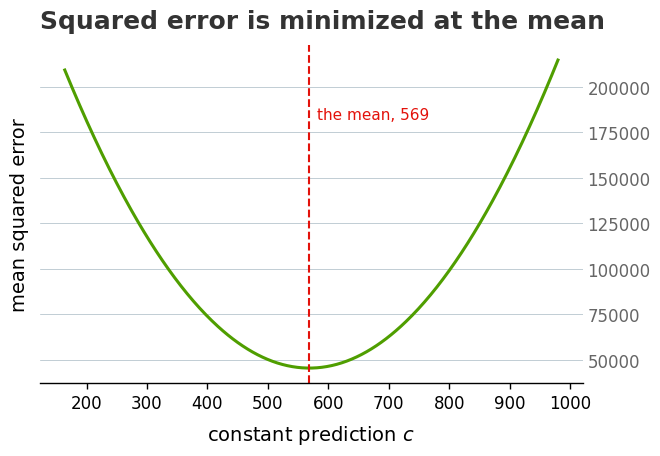

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(candidates, errors, color=mt.GREEN, lw=2.2)
ax.axvline(baseline, color=mt.RED, ls='--', lw=1.5)
ax.text(baseline + 12, errors.max() * 0.85,
        f'the mean, {baseline:.0f}', color=mt.RED, fontsize=11)
ax.set_xlabel('constant prediction $c$')
ax.set_ylabel('mean squared error')
mt.apply_book_style(ax, title='Squared error is minimized at the mean',
                    y_label_right=False)
plt.show()

The curve is a parabola with its vertex at the mean. This is the first instance of a pattern that runs through the whole book: *choose a loss, and the loss chooses the estimate.* Squared error picks the mean. Absolute error would pick the median instead, which is worth trying below.

## 4. What One Feature Buys

Now let the prediction depend on `area`. Chapter 2 derives the least-squares line; here we just fit it and ask how much of the baseline error it removes.

In [6]:
# Least-squares line, computed from the definitions rather than a library call.
area_centered = area - area.mean()
price_centered = price - price.mean()

slope = (area_centered * price_centered).sum() / (area_centered ** 2).sum()
intercept = price.mean() - slope * area.mean()

fitted = intercept + slope * area
mse_line = ((price - fitted) ** 2).mean()

print(f"price = {intercept:.1f} + {slope:.2f} * area")
print(f"line MSE     = {mse_line:9.1f}   (baseline was {mse_baseline:.1f})")
print(f"error removed = {1 - mse_line / mse_baseline:8.1%}")

price = 17.5 + 3.81 * area
line MSE     =     738.7   (baseline was 45536.0)
error removed =    98.4%


That last number has a name you already know: it is $R^2$, the fraction of the baseline's squared error that the model removes. Read this way, $R^2$ is not a mysterious goodness-of-fit index but a comparison against the do-nothing model.

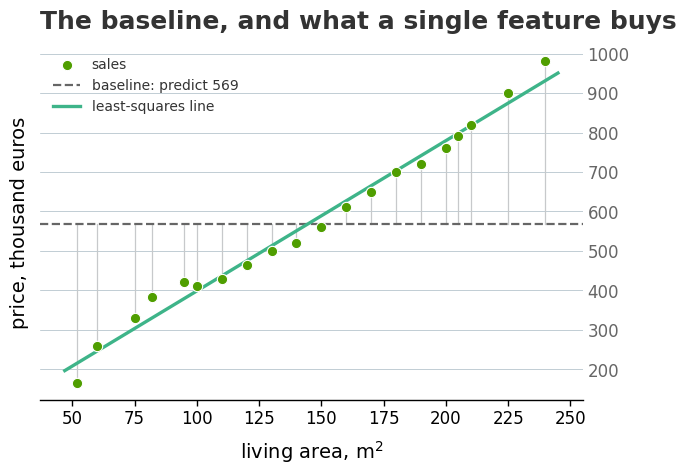

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(area, price, s=55, color=mt.GREEN, edgecolors='white',
           linewidths=0.8, zorder=3, label='sales')
ax.axhline(baseline, color=mt.GRAY, ls='--', lw=1.6,
           label=f'baseline: predict {baseline:.0f}')
grid = np.linspace(area.min() - 5, area.max() + 5, 50)
ax.plot(grid, intercept + slope * grid, color=mt.SEAFOAM, lw=2.4,
        label='least-squares line')

# The vertical gaps to the baseline are the error the line is trying to remove.
for a, p in zip(area, price):
    ax.plot([a, a], [baseline, p], color=mt.GRAY_LIGHT, lw=0.9, zorder=1)

ax.set_xlabel('living area, m$^2$')
ax.set_ylabel('price, thousand euros')
mt.apply_book_style(ax, title='The baseline, and what a single feature buys',
                    y_label_right=False)
ax.legend(frameon=False, fontsize=10, loc='upper left')
plt.show()

The gray segments are what the baseline gets wrong. Tilting the flat line to follow the data absorbs most of it, which is the whole of Chapter 2 in one picture.

## 5. Baselines for Classification

The same discipline applies when the target is a label. There the do-nothing model predicts the majority class, and its accuracy is the base rate. A classifier that cannot beat it has learned nothing, however impressive its accuracy looks in isolation.

In [8]:
# 950 negatives, 50 positives: a deliberately imbalanced screening problem.
labels = np.concatenate([np.zeros(950), np.ones(50)])

majority = 0.0 if (labels == 0).sum() > (labels == 1).sum() else 1.0
baseline_accuracy = (labels == majority).mean()

print(f"majority class      = {majority:.0f}")
print(f"baseline accuracy   = {baseline_accuracy:.1%}")
print(f"positives it finds  = 0 of {int(labels.sum())}")

majority class      = 0
baseline accuracy   = 95.0%
positives it finds  = 0 of 50


A model reported at 95% accuracy on this problem has done exactly as well as predicting "no" a thousand times in a row. Chapter 6 builds the vocabulary for saying what is wrong with that report; Chapter 1's contribution is the habit of asking for the baseline first.

## What to Try Next

- Replace squared error with absolute error in the scan of Section 3. Where does the minimum move, and why?
- Drop the largest sale from the data and refit. Which changes more, the mean or the least-squares slope?
- Add a second feature of your own invention (say, rooms) and see whether the error removed goes up by enough to justify it. Chapters 5 and 6 make that question precise.